In [1]:
import os
import random
import time
import joblib
import numpy as np
import polars as pl
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
# from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ART

from art.attacks.evasion import ProjectedGradientDescent, FastGradientMethod
from art.estimators.classification import TensorFlowV2Classifier, SklearnClassifier, XGBoostClassifier, LightGBMClassifier, CatBoostARTClassifier, KerasClassifier

I0000 00:00:1779186603.196162 1022196 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779186603.249604 1022196 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779186604.442614 1022196 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packa

In [2]:
# Configuración de visualización

sns.set_style("whitegrid")

HAS_GPU = len(tf.config.list_physical_devices("GPU")) > 0
TRAIN_DEVICE = "/GPU:0" if HAS_GPU else "/CPU:0"
INFER_DEVICE = "/CPU:0"

SEED = 42
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

if HAS_GPU:
    print("GPU detectada. Se entrenarán los modelos compatibles en GPU y se medirá la inferencia en CPU cuando aplique.")
else:
    print("No hay GPU disponible. Todo el notebook se ejecutará en CPU.")

tf.keras.backend.clear_session()

def build_mlp_model(input_dim, hidden_units):
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(input_shape=(input_dim,)))
    for units in hidden_units:
        model.add(keras.layers.Dense(units, activation="relu"))
    model.add(keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


DEFAULT_CNN_DROPOUT = 0.2

def build_cnn1d_model(n_features, n_filters, kernel_size, dense_units, dropout_rate=DEFAULT_CNN_DROPOUT):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features, 1)),
        keras.layers.Conv1D(filters=n_filters, kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(filters=max(16, n_filters // 2), kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(dense_units, activation="relu"),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def clone_keras_model_to_cpu(builder_fn, trained_model, *builder_args):
    with tf.device(INFER_DEVICE):
        cpu_model = builder_fn(*builder_args)
        cpu_model.set_weights(trained_model.get_weights())
    return cpu_model

GPU detectada. Se entrenarán los modelos compatibles en GPU y se medirá la inferencia en CPU cuando aplique.


In [3]:
# ==========================================
# 1. CARGA DE DATOS
# ==========================================

TARGET_COL = "label"
prepared_path = "../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_preparado.csv"

df_encoded = pl.read_csv(prepared_path)

feature_columns = [col for col in df_encoded.columns if col != TARGET_COL]
X = df_encoded.select(feature_columns)
y_np = df_encoded[TARGET_COL].to_numpy().astype(np.int8)
X_np = X.to_numpy().astype(np.float32)

indices = np.arange(X_np.shape[0])

train_full_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=y_np,
)

train_idx, val_idx = train_test_split(
    train_full_idx,
    test_size=0.2,
    random_state=SEED,
    stratify=y_np[train_full_idx],
)

X_full_train_np = X_np[train_full_idx]
X_test_np = X_np[test_idx]
y_full_train = y_np[train_full_idx]
y_test_np = y_np[test_idx]

X_train_np = X_np[train_idx]
X_val_np = X_np[val_idx]
y_train_np = y_np[train_idx]
y_val_np = y_np[val_idx]

print(f"Entrenamiento: {len(X_train_np):,} muestras")
print(f"Validación:    {len(X_val_np):,} muestras")
print(f"Test:          {len(X_test_np):,} muestras")
print(f"Clases en test: {np.unique(y_test_np)}")
print(f"Total muestras: {len(X_np):,}")
print("La clase 0 corresponde a Benign y la clase 1 a Malicious.")


Entrenamiento: 745,504 muestras
Validación:    186,376 muestras
Test:          232,971 muestras
Clases en test: [0 1]
Total muestras: 1,164,851
La clase 0 corresponde a Benign y la clase 1 a Malicious.


In [4]:
# ==========================================
# 2. CONFIGURACIÓN DE LOS GANADORES
# ==========================================

RF_CONFIG = {"n_estimators": 50, "max_depth": 21}
XGB_CONFIG = {"n_estimators": 50, "max_depth": 6, "learning_rate": 0.1}
LGBM_CONFIG = {"n_estimators": 50, "num_leaves": 15, "max_depth": 6, "learning_rate": 0.1}
CATBOOST_CONFIG = {"iterations": 350, "depth": 3, "learning_rate": 0.1}

SVM_C = 0.801714
MLP_INPUT_DIM = X_full_train_np.shape[1]
MLP_HIDDEN_UNITS = (32, 48, 48)
CNN1D_CONFIG = {"nf": 64, "k": 4, "d": 80}

In [5]:
# ==========================================
# 3. ENTRENAMIENTO
# ==========================================

X_test_np_arr = np.array(X_test_np)

print("Entrenando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=RF_CONFIG["n_estimators"],
    max_depth=RF_CONFIG["max_depth"],
    n_jobs=-1,
    random_state=SEED,
    class_weight="balanced_subsample"
)
rf_model.fit(X_full_train_np, y_full_train)
joblib.dump(rf_model, os.path.join(MODEL_DIR, "rf_iot23.joblib"))

# ==========================================

print("\nEntrenando XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=XGB_CONFIG["n_estimators"],
    max_depth=XGB_CONFIG["max_depth"],
    learning_rate=XGB_CONFIG["learning_rate"],
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda" if HAS_GPU else "cpu",
    random_state=SEED,
)
xgb_model.fit(X_full_train_np, y_full_train)
joblib.dump(xgb_model, os.path.join(MODEL_DIR, "xgb_iot23.joblib"))

# ==========================================

print("\nEntrenando LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=LGBM_CONFIG["n_estimators"],
    num_leaves=LGBM_CONFIG["num_leaves"],
    max_depth=LGBM_CONFIG["max_depth"],
    learning_rate=LGBM_CONFIG["learning_rate"],
    objective="binary",
    device_type="gpu" if HAS_GPU else "cpu",
    n_jobs=-1,
    random_state=SEED,
    verbosity=-1
)
lgbm_model.fit(X_full_train_np, y_full_train)
joblib.dump(lgbm_model, os.path.join(MODEL_DIR, "lgbm_iot23.joblib"))

# ==========================================

print("\nEntrenando CatBoost...")
cat_model = CatBoostClassifier(
    iterations=CATBOOST_CONFIG["iterations"],
    depth=CATBOOST_CONFIG["depth"],
    learning_rate=CATBOOST_CONFIG["learning_rate"],
    random_seed=SEED,
    logging_level="Silent",
    task_type="GPU" if HAS_GPU else "CPU"
)
cat_model.fit(X_full_train_np, y_full_train)
joblib.dump(cat_model, os.path.join(MODEL_DIR, "catboost_iot23.joblib"))

Entrenando Random Forest...

Entrenando XGBoost...

Entrenando LightGBM...

Entrenando CatBoost...


['model/catboost_iot23.joblib']

In [6]:
# ==========================================

print("\nEntrenando Linear SVM...")
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=SVM_C, dual=False, random_state=SEED, max_iter=2000)
)
svm_model.fit(X_full_train_np, y_full_train)
joblib.dump(svm_model, os.path.join(MODEL_DIR, "svm_iot23.joblib"))

# ==========================================

print("\nPreparando vistas del dataset para cada familia de modelos...")
X_test_np_arr = np.array(X_test_np, dtype=np.float32)

mlp_scaler = StandardScaler()
X_train_scaled_mlp = mlp_scaler.fit_transform(X_full_train_np).astype(np.float32)
X_test_scaled_mlp = mlp_scaler.transform(X_test_np_arr).astype(np.float32)

cnn_scaler = MinMaxScaler()
X_train_scaled_cnn = cnn_scaler.fit_transform(X_full_train_np).astype(np.float32)
X_test_scaled_cnn = cnn_scaler.transform(X_test_np_arr).astype(np.float32)
X_train_tabular_cnn = X_train_scaled_cnn.reshape(X_train_scaled_cnn.shape[0], X_train_scaled_cnn.shape[1], 1)
X_test_tabular_cnn = X_test_scaled_cnn.reshape(X_test_scaled_cnn.shape[0], X_test_scaled_cnn.shape[1], 1)

DATASET_VIEWS = {
    "raw": {"train": X_full_train_np, "test": X_test_np_arr},
    "standard": {"train": X_train_scaled_mlp, "test": X_test_scaled_mlp},
    "minmax": {"train": X_train_scaled_cnn, "test": X_test_scaled_cnn},
}

print("Vistas disponibles:", ", ".join(DATASET_VIEWS.keys()))

# ==========================================

print("\nEntrenando TensorFlow MLP...")
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
with tf.device(INFER_DEVICE):
    mlp_model = build_mlp_model(MLP_INPUT_DIM, MLP_HIDDEN_UNITS)
    mlp_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    mlp_model.fit(
        X_train_scaled_mlp,
        y_full_train,
        validation_split=0.1,
        epochs=40,
        batch_size=2048,
        callbacks=[mlp_early],
        verbose=0
    )
joblib.dump(mlp_model, os.path.join(MODEL_DIR, "mlp_iot23.joblib"))

# ==========================================

print("\nEntrenando CNN-1D...")
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
with tf.device(INFER_DEVICE):
    cnn_model = build_cnn1d_model(X_train_tabular_cnn.shape[1], CNN1D_CONFIG["nf"], CNN1D_CONFIG["k"], CNN1D_CONFIG["d"])
    cnn_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    cnn_model.fit(
        X_train_tabular_cnn,
        y_full_train,
        validation_split=0.1,
        epochs=20,
        batch_size=1024,
        callbacks=[cnn_early],
        verbose=0
    )
joblib.dump(cnn_model, os.path.join(MODEL_DIR, "cnn_iot23.joblib"))


Entrenando Linear SVM...

Preparando vistas del dataset para cada familia de modelos...
Vistas disponibles: raw, standard, minmax

Entrenando TensorFlow MLP...


I0000 00:00:1779186626.191232 1022196 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43417 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
I0000 00:00:1779186626.201044 1022196 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43485 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9
I0000 00:00:1779186626.211611 1022196 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 16434 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:ca:00.0, compute capability: 8.9
I0000 00:00:1779186626.215817 1022196 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 15910 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:


Entrenando CNN-1D...


['model/cnn_iot23.joblib']

In [7]:
# Evaluamos en test MLP para tener un F1-score de referencia antes de los ataques adversarios

mlp_model_cpu = clone_keras_model_to_cpu(build_mlp_model, mlp_model, MLP_INPUT_DIM, MLP_HIDDEN_UNITS)
def mlp_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def mlp_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()

# F1-score de referencia en test para MLP
y_test_pred_mlp = mlp_predict_labels(X_test_scaled_mlp)
mlp_f1 = f1_score(y_test_np, y_test_pred_mlp, pos_label=0)
print(f"\nMLP F1-score en test: {mlp_f1:.4f}")


MLP F1-score en test: 0.9941


In [8]:
# Extraemos restricciones tabulares a partir del train original
feature_names = feature_columns

X_full_train_df = pl.DataFrame(X_full_train_np, schema=feature_names)

tabular_constraints_df = pl.DataFrame({
    "feature": feature_names,
    "min": X_full_train_df.min().row(0),
    "max": X_full_train_df.max().row(0),
})

feature_mins = tabular_constraints_df["min"].to_numpy().astype(np.float32)
feature_maxs = tabular_constraints_df["max"].to_numpy().astype(np.float32)

tabular_constraints = {
    feature: {"min": float(min_val), "max": float(max_val)}
    for feature, min_val, max_val in zip(feature_names, feature_mins, feature_maxs)
}

clip_values_raw = (feature_mins, feature_maxs)

feature_mins_mlp = mlp_scaler.transform(feature_mins.reshape(1, -1)).ravel().astype(np.float32)
feature_maxs_mlp = mlp_scaler.transform(feature_maxs.reshape(1, -1)).ravel().astype(np.float32)

feature_mins_cnn = cnn_scaler.transform(feature_mins.reshape(1, -1)).reshape(-1, 1).astype(np.float32)
feature_maxs_cnn = cnn_scaler.transform(feature_maxs.reshape(1, -1)).reshape(-1, 1).astype(np.float32)

one_hot_columns = [
    col for col in feature_names
    if col.startswith("proto_") or col.startswith("conn_state_")
]

attack_mask = np.array(
    [0.0 if col in one_hot_columns else 1.0 for col in feature_names],
    dtype=np.float32
)
attack_mask_cnn = attack_mask.reshape(-1, 1).astype(np.float32)

# ART exige min < max en todas las columnas.
tiny = np.float32(1e-6)
feature_maxs_mlp = np.where(feature_maxs_mlp <= feature_mins_mlp, feature_mins_mlp + tiny, feature_maxs_mlp)
feature_maxs_cnn = np.where(feature_maxs_cnn <= feature_mins_cnn, feature_mins_cnn + tiny, feature_maxs_cnn)

clip_values_mlp = (feature_mins_mlp, feature_maxs_mlp)
clip_values_cnn = (feature_mins_cnn, feature_maxs_cnn)

print("Restricciones tabulares extraidas para IOT-23:")
display(tabular_constraints_df)

print("Columnas one-hot bloqueadas:")
print(one_hot_columns)


Restricciones tabulares extraidas para IOT-23:


feature,min,max
str,f64,f64
"""id.orig_p""",3.0,65394.0
"""id.resp_p""",0.0,65535.0
"""proto_icmp""",0.0,1.0
"""proto_tcp""",0.0,1.0
"""proto_udp""",0.0,1.0
…,…,…
"""conn_state_S1""",0.0,1.0
"""conn_state_S2""",0.0,1.0
"""conn_state_SF""",0.0,1.0


Columnas one-hot bloqueadas:
['proto_icmp', 'proto_tcp', 'proto_udp', 'conn_state_OTH', 'conn_state_REJ', 'conn_state_RSTO', 'conn_state_RSTOS0', 'conn_state_RSTR', 'conn_state_RSTRH', 'conn_state_S0', 'conn_state_S1', 'conn_state_S2', 'conn_state_SF', 'conn_state_SH', 'conn_state_SHR']


In [9]:
# ==========================================
# FASE 1. ENVOLVER EL MODELO (Caja Blanca)
# ==========================================

print("Envolviendo el modelo MLP en ART con restricciones tabulares...")

clasificador_art_mlp = KerasClassifier(
    model=mlp_model_cpu,
    clip_values=clip_values_mlp,
    use_logits=False
)

print("Envolviendo el modelo CNN en ART con restricciones tabulares...")

cnn_model_cpu = clone_keras_model_to_cpu(
    build_cnn1d_model,
    cnn_model,
    X_train_tabular_cnn.shape[1],
    CNN1D_CONFIG["nf"],
    CNN1D_CONFIG["k"],
    CNN1D_CONFIG["d"]
)

clasificador_art_cnn = KerasClassifier(
    model=cnn_model_cpu,
    clip_values=clip_values_cnn,
    use_logits=False
)


Envolviendo el modelo MLP en ART con restricciones tabulares...
Envolviendo el modelo CNN en ART con restricciones tabulares...


In [10]:
# ===================================================
# FASE 2. FUERZA DE ATAQUE POR CARACTERÍSTICA (eps)
# ===================================================

print("Configurando la fuerza del ataque (eps) por característica...")

eps_base = 0.05

feature_ranges_mlp = clip_values_mlp[1] - clip_values_mlp[0]
eps_vector = (eps_base * feature_ranges_mlp).astype(np.float32)

# Las columnas one-hot no deben modificarse
eps_vector_mlp = eps_vector * attack_mask
print(eps_vector_mlp)

# ART exige eps_step > 0 en todas las columnas
tiny_step = np.float32(1e-6)
eps_step_vector_mlp = np.where(eps_vector_mlp > 0, eps_vector_mlp / 4.0, tiny_step).astype(np.float32)
print(eps_step_vector_mlp)

feature_ranges_cnn = clip_values_cnn[1] - clip_values_cnn[0]
eps_vector_cnn = (eps_base * feature_ranges_cnn).astype(np.float32)

# Conservamos el bloqueo de columnas one-hot tambien en la vista CNN
eps_vector_cnn = eps_vector_cnn * attack_mask_cnn
print(eps_vector_cnn)

eps_step_vector_cnn = np.where(eps_vector_cnn > 0, eps_vector_cnn / 4.0, tiny_step).astype(np.float32)
print(eps_step_vector_cnn)


Configurando la fuerza del ataque (eps) por característica...
[ 0.33812526  0.16436736  0.          0.          0.         48.22424
  7.1204505   3.0582452  41.2263     45.8237      0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.        ]
[8.4531315e-02 4.1091841e-02 1.0000000e-06 1.0000000e-06 1.0000000e-06
 1.2056060e+01 1.7801126e+00 7.6456130e-01 1.0306575e+01 1.1455925e+01
 1.0000000e-06 1.0000000e-06 1.0000000e-06 1.0000000e-06 1.0000000e-06
 1.0000000e-06 1.0000000e-06 1.0000000e-06 1.0000000e-06 1.0000000e-06
 1.0000000e-06 1.0000000e-06]
[[0.05]
 [0.05]
 [0.  ]
 [0.  ]
 [0.  ]
 [0.05]
 [0.05]
 [0.05]
 [0.05]
 [0.05]
 [0.  ]
 [0.  ]
 [0.  ]
 [0.  ]
 [0.  ]
 [0.  ]
 [0.  ]
 [0.  ]
 [0.  ]
 [0.  ]
 [0.  ]
 [0.  ]]
[[1.2500000e-02]
 [1.2500000e-02]
 [1.0000000e-06]
 [1.0000000e-06]
 [1.0000000e-06]
 [1.2500000e-02]
 [1.2499999e-02]
 [1.2500000e-02]
 [1.2499999e-02]
 [1.2500000e-02]
 [1.0000000e-06]
 [1.000000

In [11]:
# =======================================================
# FASE 3. LANZAR ATAQUE PGD CON RESTRICCIONES TABULARES
# =======================================================

print("Lanzando ataque PGD sobre MLP y CNN...")

# -----------------------------
# PGD sobre el MLP
# -----------------------------
ataque_pgd_mlp = ProjectedGradientDescent(
    estimator=clasificador_art_mlp,
    eps=eps_vector_mlp,
    eps_step=eps_step_vector_mlp,
    max_iter=20,
    batch_size=128
)

x_test_mlp_attack = X_test_scaled_mlp.astype(np.float32)
x_test_pgd_mlp = ataque_pgd_mlp.generate(
    x=x_test_mlp_attack,
    mask=attack_mask
)
print("¡Tráfico adversario PGD para el MLP generado con éxito!")


Lanzando ataque PGD sobre MLP y CNN...


PGD - Random Initializations: 100%|██████████| 1/1 [00:00<00:00,  6.64it/s]


¡Tráfico adversario PGD para el MLP generado con éxito!


In [12]:
# -----------------------------
# PGD sobre la CNN
# -----------------------------
ataque_pgd_cnn = ProjectedGradientDescent(
    estimator=clasificador_art_cnn,
    eps=eps_vector_cnn,
    eps_step=eps_step_vector_cnn,
    max_iter=20,
    batch_size=128
)

x_test_cnn_attack = X_test_tabular_cnn.astype(np.float32)
with tf.device(INFER_DEVICE):
    x_test_pgd_cnn = ataque_pgd_cnn.generate(
        x=x_test_cnn_attack,
        mask=attack_mask_cnn
    )

print("¡Tráfico adversario PGD para la CNN generado con éxito!")

PGD - Random Initializations: 100%|██████████| 1/1 [00:00<00:00,  4.09it/s]


¡Tráfico adversario PGD para la CNN generado con éxito!


In [13]:
# =======================================================================
# ADAPTACIÓN DE LOS DATASETS ADVERSARIOS PARA EVALUACIÓN EN AMBOS MODELOS
# =======================================================================

def cnn_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = cnn_model.predict(X, batch_size=4096, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)

# =========================
# PGD generado sobre MLP
# =========================
x_test_pgd_mlp_std = x_test_pgd_mlp.astype(np.float32)
x_test_pgd_mlp_raw = mlp_scaler.inverse_transform(x_test_pgd_mlp_std).astype(np.float32)
x_test_pgd_mlp_minmax = cnn_scaler.transform(x_test_pgd_mlp_raw).astype(np.float32)
x_test_pgd_mlp_cnn = x_test_pgd_mlp_minmax.reshape(
    x_test_pgd_mlp_minmax.shape[0],
    x_test_pgd_mlp_minmax.shape[1],
    1
)

# =========================
# PGD generado sobre CNN
# =========================
x_test_pgd_cnn_cnn = x_test_pgd_cnn.astype(np.float32)
x_test_pgd_cnn_minmax = x_test_pgd_cnn_cnn.reshape(
    x_test_pgd_cnn_cnn.shape[0],
    x_test_pgd_cnn_cnn.shape[1]
).astype(np.float32)
x_test_pgd_cnn_raw = cnn_scaler.inverse_transform(x_test_pgd_cnn_minmax).astype(np.float32)
x_test_pgd_cnn_std = mlp_scaler.transform(x_test_pgd_cnn_raw).astype(np.float32)


In [14]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

# =====================================================
# RF
# =====================================================
y_test_pred_rf_clean = rf_model.predict(X_test_np)
rf_acc_clean = accuracy_score(y_test_np, y_test_pred_rf_clean)
rf_f1_clean = f1_score(y_test_np, y_test_pred_rf_clean, pos_label=0)
rf_recall_clean = recall_score(y_test_np, y_test_pred_rf_clean, pos_label=0)

print(f"\nRF Accuracy limpio: {rf_acc_clean:.4f}")
print(f"RF F1 limpio: {rf_f1_clean:.4f}")
print(f"RF Recall limpio: {rf_recall_clean:.4f}")

y_test_pred_rf_pgd_mlp = rf_model.predict(x_test_pgd_mlp_raw)
rf_acc_pgd_mlp = accuracy_score(y_test_np, y_test_pred_rf_pgd_mlp)
rf_f1_pgd_mlp = f1_score(y_test_np, y_test_pred_rf_pgd_mlp, pos_label=0)
rf_recall_pgd_mlp = recall_score(y_test_np, y_test_pred_rf_pgd_mlp, pos_label=0)

print(f"\nRF Accuracy PGD-MLP: {rf_acc_pgd_mlp:.4f}")
print(f"RF F1 PGD-MLP: {rf_f1_pgd_mlp:.4f}")
print(f"RF Recall PGD-MLP: {rf_recall_pgd_mlp:.4f}")

y_test_pred_rf_pgd_cnn = rf_model.predict(x_test_pgd_cnn_raw)
rf_acc_pgd_cnn = accuracy_score(y_test_np, y_test_pred_rf_pgd_cnn)
rf_f1_pgd_cnn = f1_score(y_test_np, y_test_pred_rf_pgd_cnn, pos_label=0)
rf_recall_pgd_cnn = recall_score(y_test_np, y_test_pred_rf_pgd_cnn, pos_label=0)

print(f"\nRF Accuracy PGD-CNN: {rf_acc_pgd_cnn:.4f}")
print(f"RF F1 PGD-CNN: {rf_f1_pgd_cnn:.4f}")
print(f"RF Recall PGD-CNN: {rf_recall_pgd_cnn:.4f}")

# =====================================================
# XGBOOST
# =====================================================
y_test_pred_xgb_clean = xgb_model.predict(X_test_np)
xgb_acc_clean = accuracy_score(y_test_np, y_test_pred_xgb_clean)
xgb_f1_clean = f1_score(y_test_np, y_test_pred_xgb_clean, pos_label=0)
xgb_recall_clean = recall_score(y_test_np, y_test_pred_xgb_clean, pos_label=0)

print(f"\nXGB Accuracy limpio: {xgb_acc_clean:.4f}")
print(f"XGB F1 limpio: {xgb_f1_clean:.4f}")
print(f"XGB Recall limpio: {xgb_recall_clean:.4f}")

y_test_pred_xgb_pgd_mlp = xgb_model.predict(x_test_pgd_mlp_raw)
xgb_acc_pgd_mlp = accuracy_score(y_test_np, y_test_pred_xgb_pgd_mlp)
xgb_f1_pgd_mlp = f1_score(y_test_np, y_test_pred_xgb_pgd_mlp, pos_label=0)
xgb_recall_pgd_mlp = recall_score(y_test_np, y_test_pred_xgb_pgd_mlp, pos_label=0)

print(f"\nXGB Accuracy PGD-MLP: {xgb_acc_pgd_mlp:.4f}")
print(f"XGB F1 PGD-MLP: {xgb_f1_pgd_mlp:.4f}")
print(f"XGB Recall PGD-MLP: {xgb_recall_pgd_mlp:.4f}")

y_test_pred_xgb_pgd_cnn = xgb_model.predict(x_test_pgd_cnn_raw)
xgb_acc_pgd_cnn = accuracy_score(y_test_np, y_test_pred_xgb_pgd_cnn)
xgb_f1_pgd_cnn = f1_score(y_test_np, y_test_pred_xgb_pgd_cnn, pos_label=0)
xgb_recall_pgd_cnn = recall_score(y_test_np, y_test_pred_xgb_pgd_cnn, pos_label=0)

print(f"\nXGB Accuracy PGD-CNN: {xgb_acc_pgd_cnn:.4f}")
print(f"XGB F1 PGD-CNN: {xgb_f1_pgd_cnn:.4f}")
print(f"XGB Recall PGD-CNN: {xgb_recall_pgd_cnn:.4f}")

# =====================================================
# LIGHTGBM
# =====================================================
y_test_pred_lgbm_clean = lgbm_model.predict(X_test_np)
lgbm_acc_clean = accuracy_score(y_test_np, y_test_pred_lgbm_clean)
lgbm_f1_clean = f1_score(y_test_np, y_test_pred_lgbm_clean, pos_label=0)
lgbm_recall_clean = recall_score(y_test_np, y_test_pred_lgbm_clean, pos_label=0)

print(f"\nLGBM Accuracy limpio: {lgbm_acc_clean:.4f}")
print(f"LGBM F1 limpio: {lgbm_f1_clean:.4f}")
print(f"LGBM Recall limpio: {lgbm_recall_clean:.4f}")

y_test_pred_lgbm_pgd_mlp = lgbm_model.predict(x_test_pgd_mlp_raw)
lgbm_acc_pgd_mlp = accuracy_score(y_test_np, y_test_pred_lgbm_pgd_mlp)
lgbm_f1_pgd_mlp = f1_score(y_test_np, y_test_pred_lgbm_pgd_mlp, pos_label=0)
lgbm_recall_pgd_mlp = recall_score(y_test_np, y_test_pred_lgbm_pgd_mlp, pos_label=0)

print(f"\nLGBM Accuracy PGD-MLP: {lgbm_acc_pgd_mlp:.4f}")
print(f"LGBM F1 PGD-MLP: {lgbm_f1_pgd_mlp:.4f}")
print(f"LGBM Recall PGD-MLP: {lgbm_recall_pgd_mlp:.4f}")

y_test_pred_lgbm_pgd_cnn = lgbm_model.predict(x_test_pgd_cnn_raw)
lgbm_acc_pgd_cnn = accuracy_score(y_test_np, y_test_pred_lgbm_pgd_cnn)
lgbm_f1_pgd_cnn = f1_score(y_test_np, y_test_pred_lgbm_pgd_cnn, pos_label=0)
lgbm_recall_pgd_cnn = recall_score(y_test_np, y_test_pred_lgbm_pgd_cnn, pos_label=0)

print(f"\nLGBM Accuracy PGD-CNN: {lgbm_acc_pgd_cnn:.4f}")
print(f"LGBM F1 PGD-CNN: {lgbm_f1_pgd_cnn:.4f}")
print(f"LGBM Recall PGD-CNN: {lgbm_recall_pgd_cnn:.4f}")

# =====================================================
# CATBOOST
# =====================================================
y_test_pred_cat_clean = cat_model.predict(X_test_np)
cat_acc_clean = accuracy_score(y_test_np, y_test_pred_cat_clean)
cat_f1_clean = f1_score(y_test_np, y_test_pred_cat_clean, pos_label=0)
cat_recall_clean = recall_score(y_test_np, y_test_pred_cat_clean, pos_label=0)

print(f"\nCatBoost Accuracy limpio: {cat_acc_clean:.4f}")
print(f"CatBoost F1 limpio: {cat_f1_clean:.4f}")
print(f"CatBoost Recall limpio: {cat_recall_clean:.4f}")

y_test_pred_cat_pgd_mlp = cat_model.predict(x_test_pgd_mlp_raw)
cat_acc_pgd_mlp = accuracy_score(y_test_np, y_test_pred_cat_pgd_mlp)
cat_f1_pgd_mlp = f1_score(y_test_np, y_test_pred_cat_pgd_mlp, pos_label=0)
cat_recall_pgd_mlp = recall_score(y_test_np, y_test_pred_cat_pgd_mlp, pos_label=0)

print(f"\nCatBoost Accuracy PGD-MLP: {cat_acc_pgd_mlp:.4f}")
print(f"CatBoost F1 PGD-MLP: {cat_f1_pgd_mlp:.4f}")
print(f"CatBoost Recall PGD-MLP: {cat_recall_pgd_mlp:.4f}")

y_test_pred_cat_pgd_cnn = cat_model.predict(x_test_pgd_cnn_raw)
cat_acc_pgd_cnn = accuracy_score(y_test_np, y_test_pred_cat_pgd_cnn)
cat_f1_pgd_cnn = f1_score(y_test_np, y_test_pred_cat_pgd_cnn, pos_label=0)
cat_recall_pgd_cnn = recall_score(y_test_np, y_test_pred_cat_pgd_cnn, pos_label=0)

print(f"\nCatBoost Accuracy PGD-CNN: {cat_acc_pgd_cnn:.4f}")
print(f"CatBoost F1 PGD-CNN: {cat_f1_pgd_cnn:.4f}")
print(f"CatBoost Recall PGD-CNN: {cat_recall_pgd_cnn:.4f}")

# =====================================================
# SVM
# =====================================================
y_test_pred_svm_clean = svm_model.predict(X_test_np)
svm_acc_clean = accuracy_score(y_test_np, y_test_pred_svm_clean)
svm_f1_clean = f1_score(y_test_np, y_test_pred_svm_clean, pos_label=0)
svm_recall_clean = recall_score(y_test_np, y_test_pred_svm_clean, pos_label=0)

print(f"\nSVM Accuracy limpio: {svm_acc_clean:.4f}")
print(f"SVM F1 limpio: {svm_f1_clean:.4f}")
print(f"SVM Recall limpio: {svm_recall_clean:.4f}")

y_test_pred_svm_pgd_mlp = svm_model.predict(x_test_pgd_mlp_raw)
svm_acc_pgd_mlp = accuracy_score(y_test_np, y_test_pred_svm_pgd_mlp)
svm_f1_pgd_mlp = f1_score(y_test_np, y_test_pred_svm_pgd_mlp, pos_label=0)
svm_recall_pgd_mlp = recall_score(y_test_np, y_test_pred_svm_pgd_mlp, pos_label=0)

print(f"\nSVM Accuracy PGD-MLP: {svm_acc_pgd_mlp:.4f}")
print(f"SVM F1 PGD-MLP: {svm_f1_pgd_mlp:.4f}")
print(f"SVM Recall PGD-MLP: {svm_recall_pgd_mlp:.4f}")

y_test_pred_svm_pgd_cnn = svm_model.predict(x_test_pgd_cnn_raw)
svm_acc_pgd_cnn = accuracy_score(y_test_np, y_test_pred_svm_pgd_cnn)
svm_f1_pgd_cnn = f1_score(y_test_np, y_test_pred_svm_pgd_cnn, pos_label=0)
svm_recall_pgd_cnn = recall_score(y_test_np, y_test_pred_svm_pgd_cnn, pos_label=0)

print(f"\nSVM Accuracy PGD-CNN: {svm_acc_pgd_cnn:.4f}")
print(f"SVM F1 PGD-CNN: {svm_f1_pgd_cnn:.4f}")
print(f"SVM Recall PGD-CNN: {svm_recall_pgd_cnn:.4f}")

# =====================================================
# MLP
# =====================================================
y_test_pred_mlp_clean = mlp_predict_labels(X_test_scaled_mlp)
mlp_acc_clean = accuracy_score(y_test_np, y_test_pred_mlp_clean)
mlp_f1_clean = f1_score(y_test_np, y_test_pred_mlp_clean, pos_label=0)
mlp_recall_clean = recall_score(y_test_np, y_test_pred_mlp_clean, pos_label=0)

print(f"\nMLP Accuracy limpio: {mlp_acc_clean:.4f}")
print(f"MLP F1 limpio: {mlp_f1_clean:.4f}")
print(f"MLP Recall limpio: {mlp_recall_clean:.4f}")

y_test_pred_mlp_pgd_mlp = mlp_predict_labels(x_test_pgd_mlp_std)
mlp_acc_pgd_mlp = accuracy_score(y_test_np, y_test_pred_mlp_pgd_mlp)
mlp_f1_pgd_mlp = f1_score(y_test_np, y_test_pred_mlp_pgd_mlp, pos_label=0)
mlp_recall_pgd_mlp = recall_score(y_test_np, y_test_pred_mlp_pgd_mlp, pos_label=0)

print(f"\nMLP Accuracy PGD-MLP: {mlp_acc_pgd_mlp:.4f}")
print(f"MLP F1 PGD-MLP: {mlp_f1_pgd_mlp:.4f}")
print(f"MLP Recall PGD-MLP: {mlp_recall_pgd_mlp:.4f}")

y_test_pred_mlp_pgd_cnn = mlp_predict_labels(x_test_pgd_cnn_std)
mlp_acc_pgd_cnn = accuracy_score(y_test_np, y_test_pred_mlp_pgd_cnn)
mlp_f1_pgd_cnn = f1_score(y_test_np, y_test_pred_mlp_pgd_cnn, pos_label=0)
mlp_recall_pgd_cnn = recall_score(y_test_np, y_test_pred_mlp_pgd_cnn, pos_label=0)

print(f"\nMLP Accuracy PGD-CNN: {mlp_acc_pgd_cnn:.4f}")
print(f"MLP F1 PGD-CNN: {mlp_f1_pgd_cnn:.4f}")
print(f"MLP Recall PGD-CNN: {mlp_recall_pgd_cnn:.4f}")

# =====================================================
# CNN
# =====================================================
y_test_pred_cnn_clean = cnn_predict_labels(X_test_tabular_cnn)
cnn_acc_clean = accuracy_score(y_test_np, y_test_pred_cnn_clean)
cnn_f1_clean = f1_score(y_test_np, y_test_pred_cnn_clean, pos_label=0)
cnn_recall_clean = recall_score(y_test_np, y_test_pred_cnn_clean, pos_label=0)

print(f"\nCNN Accuracy limpio: {cnn_acc_clean:.4f}")
print(f"CNN F1 limpio: {cnn_f1_clean:.4f}")
print(f"CNN Recall limpio: {cnn_recall_clean:.4f}")

y_test_pred_cnn_pgd_mlp = cnn_predict_labels(x_test_pgd_mlp_cnn)
cnn_acc_pgd_mlp = accuracy_score(y_test_np, y_test_pred_cnn_pgd_mlp)
cnn_f1_pgd_mlp = f1_score(y_test_np, y_test_pred_cnn_pgd_mlp, pos_label=0)
cnn_recall_pgd_mlp = recall_score(y_test_np, y_test_pred_cnn_pgd_mlp, pos_label=0)

print(f"\nCNN Accuracy PGD-MLP: {cnn_acc_pgd_mlp:.4f}")
print(f"CNN F1 PGD-MLP: {cnn_f1_pgd_mlp:.4f}")
print(f"CNN Recall PGD-MLP: {cnn_recall_pgd_mlp:.4f}")

y_test_pred_cnn_pgd_cnn = cnn_predict_labels(x_test_pgd_cnn_cnn)
cnn_acc_pgd_cnn = accuracy_score(y_test_np, y_test_pred_cnn_pgd_cnn)
cnn_f1_pgd_cnn = f1_score(y_test_np, y_test_pred_cnn_pgd_cnn, pos_label=0)
cnn_recall_pgd_cnn = recall_score(y_test_np, y_test_pred_cnn_pgd_cnn, pos_label=0)

print(f"\nCNN Accuracy PGD-CNN: {cnn_acc_pgd_cnn:.4f}")
print(f"CNN F1 PGD-CNN: {cnn_f1_pgd_cnn:.4f}")
print(f"CNN Recall PGD-CNN: {cnn_recall_pgd_cnn:.4f}")



RF Accuracy limpio: 0.9996
RF F1 limpio: 0.9995
RF Recall limpio: 0.9991

RF Accuracy PGD-MLP: 0.5503
RF F1 PGD-MLP: 0.6421
RF Recall PGD-MLP: 0.9918

RF Accuracy PGD-CNN: 0.5289
RF F1 PGD-CNN: 0.6307
RF Recall PGD-CNN: 0.9887


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [12:47:05] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



XGB Accuracy limpio: 0.9990
XGB F1 limpio: 0.9987
XGB Recall limpio: 0.9975

XGB Accuracy PGD-MLP: 0.4817
XGB F1 PGD-MLP: 0.6094
XGB Recall PGD-MLP: 0.9941

XGB Accuracy PGD-CNN: 0.4076
XGB F1 PGD-CNN: 0.5786
XGB Recall PGD-CNN: 1.0000


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LGBM Accuracy limpio: 0.9998
LGBM F1 limpio: 0.9998
LGBM Recall limpio: 0.9997

LGBM Accuracy PGD-MLP: 0.5116
LGBM F1 PGD-MLP: 0.6247
LGBM Recall PGD-MLP: 0.9994

LGBM Accuracy PGD-CNN: 0.4067
LGBM F1 PGD-CNN: 0.5770
LGBM Recall PGD-CNN: 0.9947

CatBoost Accuracy limpio: 1.0000
CatBoost F1 limpio: 1.0000
CatBoost Recall limpio: 0.9999

CatBoost Accuracy PGD-MLP: 0.5270
CatBoost F1 PGD-MLP: 0.6321
CatBoost Recall PGD-MLP: 0.9991

CatBoost Accuracy PGD-CNN: 0.9308
CatBoost F1 PGD-CNN: 0.9208
CatBoost Recall PGD-CNN: 0.9890

SVM Accuracy limpio: 0.9460
SVM F1 limpio: 0.9324
SVM Recall limpio: 0.9159

SVM Accuracy PGD-MLP: 0.4362
SVM F1 PGD-MLP: 0.5825
SVM Recall PGD-MLP: 0.9671

SVM Accuracy PGD-CNN: 0.9435
SVM F1 PGD-CNN: 0.9299
SVM Recall PGD-CNN: 0.9215

MLP Accuracy limpio: 0.9952
MLP F1 limpio: 0.9941
MLP Recall limpio: 0.9915

MLP Accuracy PGD-MLP: 0.4446
MLP F1 PGD-MLP: 0.5940
MLP Recall PGD-MLP: 0.9988

MLP Accuracy PGD-CNN: 0.9063
MLP F1 PGD-CNN: 0.8903
MLP Recall PGD-CNN: 0.934

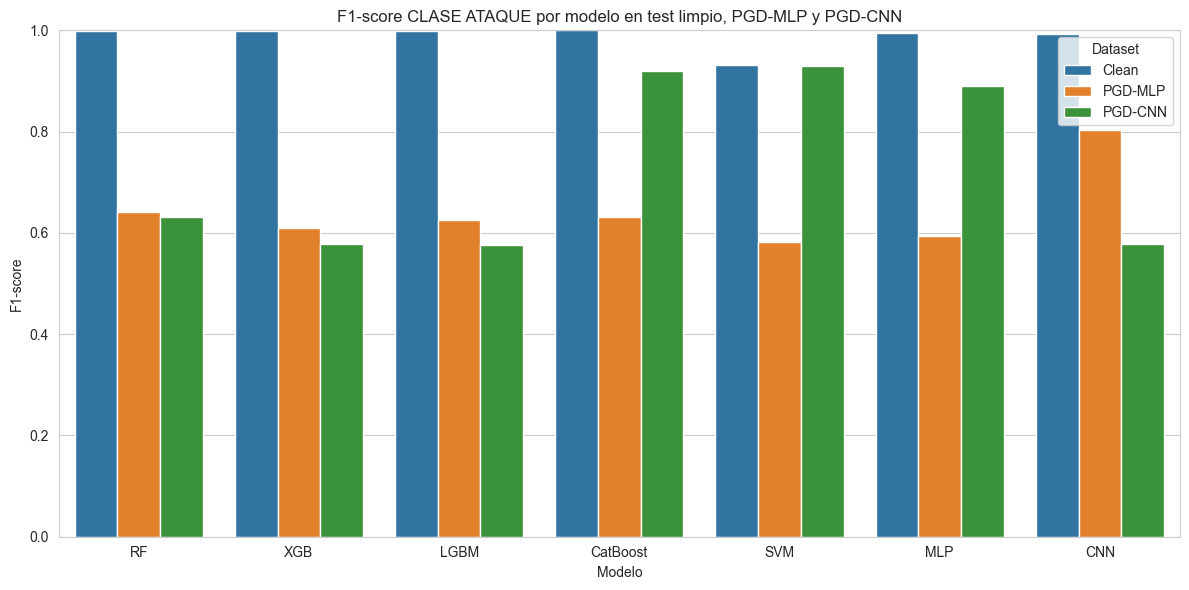

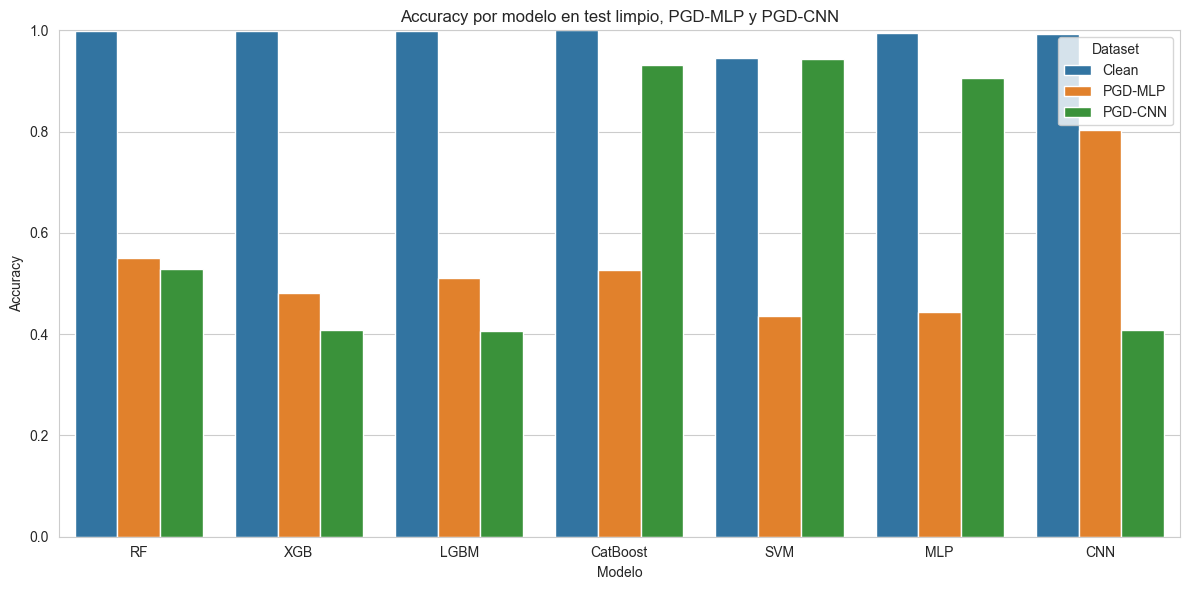

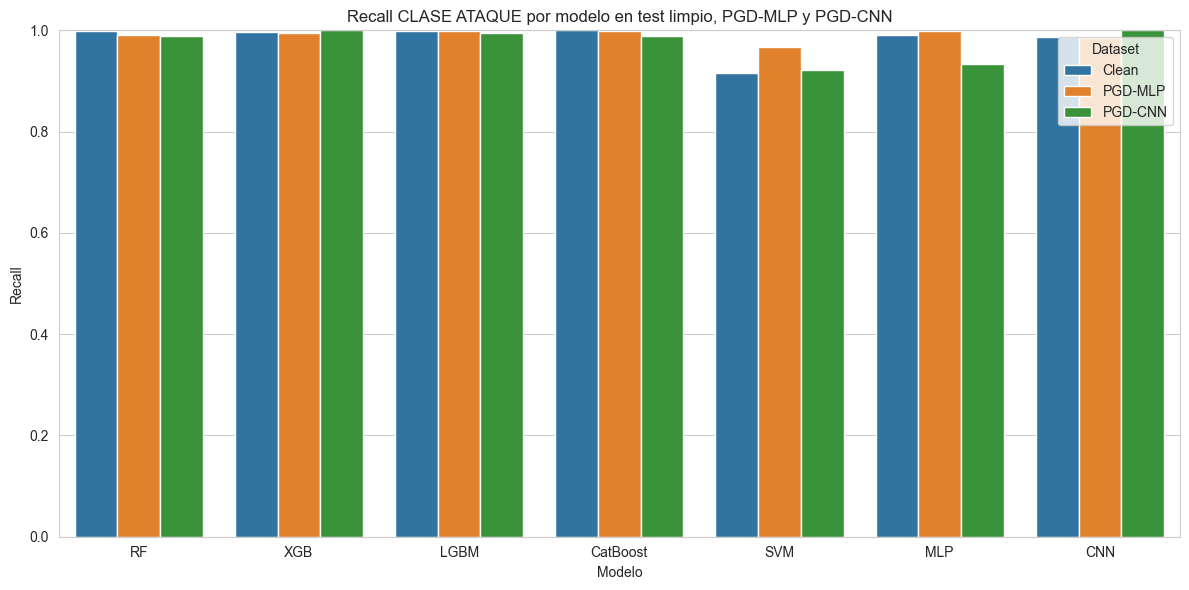

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# F1-score
# ============================================================

results_f1 = [
    {"Modelo": "RF", "Dataset": "Clean", "F1": rf_f1_clean},
    {"Modelo": "RF", "Dataset": "PGD-MLP", "F1": rf_f1_pgd_mlp},
    {"Modelo": "RF", "Dataset": "PGD-CNN", "F1": rf_f1_pgd_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "F1": xgb_f1_clean},
    {"Modelo": "XGB", "Dataset": "PGD-MLP", "F1": xgb_f1_pgd_mlp},
    {"Modelo": "XGB", "Dataset": "PGD-CNN", "F1": xgb_f1_pgd_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "F1": lgbm_f1_clean},
    {"Modelo": "LGBM", "Dataset": "PGD-MLP", "F1": lgbm_f1_pgd_mlp},
    {"Modelo": "LGBM", "Dataset": "PGD-CNN", "F1": lgbm_f1_pgd_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "F1": cat_f1_clean},
    {"Modelo": "CatBoost", "Dataset": "PGD-MLP", "F1": cat_f1_pgd_mlp},
    {"Modelo": "CatBoost", "Dataset": "PGD-CNN", "F1": cat_f1_pgd_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "F1": svm_f1_clean},
    {"Modelo": "SVM", "Dataset": "PGD-MLP", "F1": svm_f1_pgd_mlp},
    {"Modelo": "SVM", "Dataset": "PGD-CNN", "F1": svm_f1_pgd_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "F1": mlp_f1_clean},
    {"Modelo": "MLP", "Dataset": "PGD-MLP", "F1": mlp_f1_pgd_mlp},
    {"Modelo": "MLP", "Dataset": "PGD-CNN", "F1": mlp_f1_pgd_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "F1": cnn_f1_clean},
    {"Modelo": "CNN", "Dataset": "PGD-MLP", "F1": cnn_f1_pgd_mlp},
    {"Modelo": "CNN", "Dataset": "PGD-CNN", "F1": cnn_f1_pgd_cnn},
]

df_f1 = pd.DataFrame(results_f1)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_f1,
    x="Modelo",
    y="F1",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "PGD-MLP", "PGD-CNN"]
)

plt.title("F1-score CLASE ATAQUE por modelo en test limpio, PGD-MLP y PGD-CNN")
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# Accuracy
# ============================================================

results_acc = [
    {"Modelo": "RF", "Dataset": "Clean", "Accuracy": rf_acc_clean},
    {"Modelo": "RF", "Dataset": "PGD-MLP", "Accuracy": rf_acc_pgd_mlp},
    {"Modelo": "RF", "Dataset": "PGD-CNN", "Accuracy": rf_acc_pgd_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "Accuracy": xgb_acc_clean},
    {"Modelo": "XGB", "Dataset": "PGD-MLP", "Accuracy": xgb_acc_pgd_mlp},
    {"Modelo": "XGB", "Dataset": "PGD-CNN", "Accuracy": xgb_acc_pgd_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "Accuracy": lgbm_acc_clean},
    {"Modelo": "LGBM", "Dataset": "PGD-MLP", "Accuracy": lgbm_acc_pgd_mlp},
    {"Modelo": "LGBM", "Dataset": "PGD-CNN", "Accuracy": lgbm_acc_pgd_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "Accuracy": cat_acc_clean},
    {"Modelo": "CatBoost", "Dataset": "PGD-MLP", "Accuracy": cat_acc_pgd_mlp},
    {"Modelo": "CatBoost", "Dataset": "PGD-CNN", "Accuracy": cat_acc_pgd_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "Accuracy": svm_acc_clean},
    {"Modelo": "SVM", "Dataset": "PGD-MLP", "Accuracy": svm_acc_pgd_mlp},
    {"Modelo": "SVM", "Dataset": "PGD-CNN", "Accuracy": svm_acc_pgd_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "Accuracy": mlp_acc_clean},
    {"Modelo": "MLP", "Dataset": "PGD-MLP", "Accuracy": mlp_acc_pgd_mlp},
    {"Modelo": "MLP", "Dataset": "PGD-CNN", "Accuracy": mlp_acc_pgd_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "Accuracy": cnn_acc_clean},
    {"Modelo": "CNN", "Dataset": "PGD-MLP", "Accuracy": cnn_acc_pgd_mlp},
    {"Modelo": "CNN", "Dataset": "PGD-CNN", "Accuracy": cnn_acc_pgd_cnn},
]

df_acc = pd.DataFrame(results_acc)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_acc,
    x="Modelo",
    y="Accuracy",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "PGD-MLP", "PGD-CNN"]
)

plt.title("Accuracy por modelo en test limpio, PGD-MLP y PGD-CNN")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# Recall
# ============================================================

results_recall = [
    {"Modelo": "RF", "Dataset": "Clean", "Recall": rf_recall_clean},
    {"Modelo": "RF", "Dataset": "PGD-MLP", "Recall": rf_recall_pgd_mlp},
    {"Modelo": "RF", "Dataset": "PGD-CNN", "Recall": rf_recall_pgd_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "Recall": xgb_recall_clean},
    {"Modelo": "XGB", "Dataset": "PGD-MLP", "Recall": xgb_recall_pgd_mlp},
    {"Modelo": "XGB", "Dataset": "PGD-CNN", "Recall": xgb_recall_pgd_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "Recall": lgbm_recall_clean},
    {"Modelo": "LGBM", "Dataset": "PGD-MLP", "Recall": lgbm_recall_pgd_mlp},
    {"Modelo": "LGBM", "Dataset": "PGD-CNN", "Recall": lgbm_recall_pgd_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "Recall": cat_recall_clean},
    {"Modelo": "CatBoost", "Dataset": "PGD-MLP", "Recall": cat_recall_pgd_mlp},
    {"Modelo": "CatBoost", "Dataset": "PGD-CNN", "Recall": cat_recall_pgd_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "Recall": svm_recall_clean},
    {"Modelo": "SVM", "Dataset": "PGD-MLP", "Recall": svm_recall_pgd_mlp},
    {"Modelo": "SVM", "Dataset": "PGD-CNN", "Recall": svm_recall_pgd_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "Recall": mlp_recall_clean},
    {"Modelo": "MLP", "Dataset": "PGD-MLP", "Recall": mlp_recall_pgd_mlp},
    {"Modelo": "MLP", "Dataset": "PGD-CNN", "Recall": mlp_recall_pgd_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "Recall": cnn_recall_clean},
    {"Modelo": "CNN", "Dataset": "PGD-MLP", "Recall": cnn_recall_pgd_mlp},
    {"Modelo": "CNN", "Dataset": "PGD-CNN", "Recall": cnn_recall_pgd_cnn},
]

df_recall = pd.DataFrame(results_recall)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_recall,
    x="Modelo",
    y="Recall",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "PGD-MLP", "PGD-CNN"]
)

plt.title("Recall CLASE ATAQUE por modelo en test limpio, PGD-MLP y PGD-CNN")
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()


In [16]:
# ========================================================
# FASE 4. LANZAR ATAQUE FGSM
# ========================================================

print("Lanzando ataque FGSM sobre MLP y CNN...")

# -----------------------------
# FGSM sobre el MLP
# -----------------------------
ataque_fgsm_mlp = FastGradientMethod(
    estimator=clasificador_art_mlp,
    eps=eps_vector_mlp,
    eps_step=eps_step_vector_mlp,
    batch_size=128,
)

x_test_fgsm_mlp = ataque_fgsm_mlp.generate(
    x=x_test_mlp_attack,
    mask=attack_mask
)
print("¡Tráfico adversario FGSM para el MLP generado con éxito!")

Lanzando ataque FGSM sobre MLP y CNN...
¡Tráfico adversario FGSM para el MLP generado con éxito!


In [17]:
# -----------------------------
# FGSM sobre la CNN
# -----------------------------
ataque_fgsm_cnn = FastGradientMethod(
    estimator=clasificador_art_cnn,
    eps=eps_vector_cnn,
    eps_step=eps_step_vector_cnn,
    batch_size=128,
)

with tf.device(INFER_DEVICE):
    x_test_fgsm_cnn = ataque_fgsm_cnn.generate(
        x=x_test_cnn_attack,
        mask=attack_mask_cnn
    )

print("¡Tráfico adversario FGSM para la CNN generado con éxito!")

¡Tráfico adversario FGSM para la CNN generado con éxito!


In [18]:
# =========================
# FGSM generado sobre MLP
# =========================
x_test_fgsm_mlp_std = x_test_fgsm_mlp.astype(np.float32)
x_test_fgsm_mlp_raw = mlp_scaler.inverse_transform(x_test_fgsm_mlp_std).astype(np.float32)
x_test_fgsm_mlp_minmax = cnn_scaler.transform(x_test_fgsm_mlp_raw).astype(np.float32)
x_test_fgsm_mlp_cnn = x_test_fgsm_mlp_minmax.reshape(
    x_test_fgsm_mlp_minmax.shape[0],
    x_test_fgsm_mlp_minmax.shape[1],
    1
)

# =========================
# FGSM generado sobre CNN
# =========================
x_test_fgsm_cnn_cnn = x_test_fgsm_cnn.astype(np.float32)
x_test_fgsm_cnn_minmax = x_test_fgsm_cnn_cnn.reshape(
    x_test_fgsm_cnn_cnn.shape[0],
    x_test_fgsm_cnn_cnn.shape[1]
).astype(np.float32)
x_test_fgsm_cnn_raw = cnn_scaler.inverse_transform(x_test_fgsm_cnn_minmax).astype(np.float32)
x_test_fgsm_cnn_std = mlp_scaler.transform(x_test_fgsm_cnn_raw).astype(np.float32)


In [19]:
# =====================================================
# RF
# =====================================================

y_test_pred_rf_fgsm_mlp = rf_model.predict(x_test_fgsm_mlp_raw)
rf_acc_fgsm_mlp = accuracy_score(y_test_np, y_test_pred_rf_fgsm_mlp)
rf_f1_fgsm_mlp = f1_score(y_test_np, y_test_pred_rf_fgsm_mlp, pos_label=0)
rf_recall_fgsm_mlp = recall_score(y_test_np, y_test_pred_rf_fgsm_mlp, pos_label=0)

print(f"\nRF Accuracy FGSM-MLP: {rf_acc_fgsm_mlp:.4f}")
print(f"RF F1 FGSM-MLP: {rf_f1_fgsm_mlp:.4f}")
print(f"RF Recall FGSM-MLP: {rf_recall_fgsm_mlp:.4f}")

y_test_pred_rf_fgsm_cnn = rf_model.predict(x_test_fgsm_cnn_raw)
rf_acc_fgsm_cnn = accuracy_score(y_test_np, y_test_pred_rf_fgsm_cnn)
rf_f1_fgsm_cnn = f1_score(y_test_np, y_test_pred_rf_fgsm_cnn, pos_label=0)
rf_recall_fgsm_cnn = recall_score(y_test_np, y_test_pred_rf_fgsm_cnn, pos_label=0)

print(f"\nRF Accuracy FGSM-CNN: {rf_acc_fgsm_cnn:.4f}")
print(f"RF F1 FGSM-CNN: {rf_f1_fgsm_cnn:.4f}")
print(f"RF Recall FGSM-CNN: {rf_recall_fgsm_cnn:.4f}")

# =====================================================
# XGBOOST
# =====================================================

y_test_pred_xgb_fgsm_mlp = xgb_model.predict(x_test_fgsm_mlp_raw)
xgb_acc_fgsm_mlp = accuracy_score(y_test_np, y_test_pred_xgb_fgsm_mlp)
xgb_f1_fgsm_mlp = f1_score(y_test_np, y_test_pred_xgb_fgsm_mlp, pos_label=0)
xgb_recall_fgsm_mlp = recall_score(y_test_np, y_test_pred_xgb_fgsm_mlp, pos_label=0)

print(f"\nXGB Accuracy FGSM-MLP: {xgb_acc_fgsm_mlp:.4f}")
print(f"XGB F1 FGSM-MLP: {xgb_f1_fgsm_mlp:.4f}")
print(f"XGB Recall FGSM-MLP: {xgb_recall_fgsm_mlp:.4f}")

y_test_pred_xgb_fgsm_cnn = xgb_model.predict(x_test_fgsm_cnn_raw)
xgb_acc_fgsm_cnn = accuracy_score(y_test_np, y_test_pred_xgb_fgsm_cnn)
xgb_f1_fgsm_cnn = f1_score(y_test_np, y_test_pred_xgb_fgsm_cnn, pos_label=0)
xgb_recall_fgsm_cnn = recall_score(y_test_np, y_test_pred_xgb_fgsm_cnn, pos_label=0)

print(f"\nXGB Accuracy FGSM-CNN: {xgb_acc_fgsm_cnn:.4f}")
print(f"XGB F1 FGSM-CNN: {xgb_f1_fgsm_cnn:.4f}")
print(f"XGB Recall FGSM-CNN: {xgb_recall_fgsm_cnn:.4f}")

# =====================================================
# LIGHTGBM
# =====================================================

y_test_pred_lgbm_fgsm_mlp = lgbm_model.predict(x_test_fgsm_mlp_raw)
lgbm_acc_fgsm_mlp = accuracy_score(y_test_np, y_test_pred_lgbm_fgsm_mlp)
lgbm_f1_fgsm_mlp = f1_score(y_test_np, y_test_pred_lgbm_fgsm_mlp, pos_label=0)
lgbm_recall_fgsm_mlp = recall_score(y_test_np, y_test_pred_lgbm_fgsm_mlp, pos_label=0)

print(f"\nLGBM Accuracy FGSM-MLP: {lgbm_acc_fgsm_mlp:.4f}")
print(f"LGBM F1 FGSM-MLP: {lgbm_f1_fgsm_mlp:.4f}")
print(f"LGBM Recall FGSM-MLP: {lgbm_recall_fgsm_mlp:.4f}")

y_test_pred_lgbm_fgsm_cnn = lgbm_model.predict(x_test_fgsm_cnn_raw)
lgbm_acc_fgsm_cnn = accuracy_score(y_test_np, y_test_pred_lgbm_fgsm_cnn)
lgbm_f1_fgsm_cnn = f1_score(y_test_np, y_test_pred_lgbm_fgsm_cnn, pos_label=0)
lgbm_recall_fgsm_cnn = recall_score(y_test_np, y_test_pred_lgbm_fgsm_cnn, pos_label=0)

print(f"\nLGBM Accuracy FGSM-CNN: {lgbm_acc_fgsm_cnn:.4f}")
print(f"LGBM F1 FGSM-CNN: {lgbm_f1_fgsm_cnn:.4f}")
print(f"LGBM Recall FGSM-CNN: {lgbm_recall_fgsm_cnn:.4f}")

# =====================================================
# CATBOOST
# =====================================================

y_test_pred_cat_fgsm_mlp = cat_model.predict(x_test_fgsm_mlp_raw)
cat_acc_fgsm_mlp = accuracy_score(y_test_np, y_test_pred_cat_fgsm_mlp)
cat_f1_fgsm_mlp = f1_score(y_test_np, y_test_pred_cat_fgsm_mlp, pos_label=0)
cat_recall_fgsm_mlp = recall_score(y_test_np, y_test_pred_cat_fgsm_mlp, pos_label=0)

print(f"\nCatBoost Accuracy FGSM-MLP: {cat_acc_fgsm_mlp:.4f}")
print(f"CatBoost F1 FGSM-MLP: {cat_f1_fgsm_mlp:.4f}")
print(f"CatBoost Recall FGSM-MLP: {cat_recall_fgsm_mlp:.4f}")

y_test_pred_cat_fgsm_cnn = cat_model.predict(x_test_fgsm_cnn_raw)
cat_acc_fgsm_cnn = accuracy_score(y_test_np, y_test_pred_cat_fgsm_cnn)
cat_f1_fgsm_cnn = f1_score(y_test_np, y_test_pred_cat_fgsm_cnn, pos_label=0)
cat_recall_fgsm_cnn = recall_score(y_test_np, y_test_pred_cat_fgsm_cnn, pos_label=0)

print(f"\nCatBoost Accuracy FGSM-CNN: {cat_acc_fgsm_cnn:.4f}")
print(f"CatBoost F1 FGSM-CNN: {cat_f1_fgsm_cnn:.4f}")
print(f"CatBoost Recall FGSM-CNN: {cat_recall_fgsm_cnn:.4f}")

# =====================================================
# SVM
# =====================================================

y_test_pred_svm_fgsm_mlp = svm_model.predict(x_test_fgsm_mlp_raw)
svm_acc_fgsm_mlp = accuracy_score(y_test_np, y_test_pred_svm_fgsm_mlp)
svm_f1_fgsm_mlp = f1_score(y_test_np, y_test_pred_svm_fgsm_mlp, pos_label=0)
svm_recall_fgsm_mlp = recall_score(y_test_np, y_test_pred_svm_fgsm_mlp, pos_label=0)

print(f"\nSVM Accuracy FGSM-MLP: {svm_acc_fgsm_mlp:.4f}")
print(f"SVM F1 FGSM-MLP: {svm_f1_fgsm_mlp:.4f}")
print(f"SVM Recall FGSM-MLP: {svm_recall_fgsm_mlp:.4f}")

y_test_pred_svm_fgsm_cnn = svm_model.predict(x_test_fgsm_cnn_raw)
svm_acc_fgsm_cnn = accuracy_score(y_test_np, y_test_pred_svm_fgsm_cnn)
svm_f1_fgsm_cnn = f1_score(y_test_np, y_test_pred_svm_fgsm_cnn, pos_label=0)
svm_recall_fgsm_cnn = recall_score(y_test_np, y_test_pred_svm_fgsm_cnn, pos_label=0)

print(f"\nSVM Accuracy FGSM-CNN: {svm_acc_fgsm_cnn:.4f}")
print(f"SVM F1 FGSM-CNN: {svm_f1_fgsm_cnn:.4f}")
print(f"SVM Recall FGSM-CNN: {svm_recall_fgsm_cnn:.4f}")

# =====================================================
# MLP
# =====================================================

y_test_pred_mlp_fgsm_mlp = mlp_predict_labels(x_test_fgsm_mlp_std)
mlp_acc_fgsm_mlp = accuracy_score(y_test_np, y_test_pred_mlp_fgsm_mlp)
mlp_f1_fgsm_mlp = f1_score(y_test_np, y_test_pred_mlp_fgsm_mlp, pos_label=0)
mlp_recall_fgsm_mlp = recall_score(y_test_np, y_test_pred_mlp_fgsm_mlp, pos_label=0)

print(f"\nMLP Accuracy FGSM-MLP: {mlp_acc_fgsm_mlp:.4f}")
print(f"MLP F1 FGSM-MLP: {mlp_f1_fgsm_mlp:.4f}")
print(f"MLP Recall FGSM-MLP: {mlp_recall_fgsm_mlp:.4f}")

y_test_pred_mlp_fgsm_cnn = mlp_predict_labels(x_test_fgsm_cnn_std)
mlp_acc_fgsm_cnn = accuracy_score(y_test_np, y_test_pred_mlp_fgsm_cnn)
mlp_f1_fgsm_cnn = f1_score(y_test_np, y_test_pred_mlp_fgsm_cnn, pos_label=0)
mlp_recall_fgsm_cnn = recall_score(y_test_np, y_test_pred_mlp_fgsm_cnn, pos_label=0)

print(f"\nMLP Accuracy FGSM-CNN: {mlp_acc_fgsm_cnn:.4f}")
print(f"MLP F1 FGSM-CNN: {mlp_f1_fgsm_cnn:.4f}")
print(f"MLP Recall FGSM-CNN: {mlp_recall_fgsm_cnn:.4f}")

# =====================================================
# CNN
# =====================================================

y_test_pred_cnn_fgsm_mlp = cnn_predict_labels(x_test_fgsm_mlp_cnn)
cnn_acc_fgsm_mlp = accuracy_score(y_test_np, y_test_pred_cnn_fgsm_mlp)
cnn_f1_fgsm_mlp = f1_score(y_test_np, y_test_pred_cnn_fgsm_mlp, pos_label=0)
cnn_recall_fgsm_mlp = recall_score(y_test_np, y_test_pred_cnn_fgsm_mlp, pos_label=0)

print(f"\nCNN Accuracy FGSM-MLP: {cnn_acc_fgsm_mlp:.4f}")
print(f"CNN F1 FGSM-MLP: {cnn_f1_fgsm_mlp:.4f}")
print(f"CNN Recall FGSM-MLP: {cnn_recall_fgsm_mlp:.4f}")

y_test_pred_cnn_fgsm_cnn = cnn_predict_labels(x_test_fgsm_cnn_cnn)
cnn_acc_fgsm_cnn = accuracy_score(y_test_np, y_test_pred_cnn_fgsm_cnn)
cnn_f1_fgsm_cnn = f1_score(y_test_np, y_test_pred_cnn_fgsm_cnn, pos_label=0)
cnn_recall_fgsm_cnn = recall_score(y_test_np, y_test_pred_cnn_fgsm_cnn, pos_label=0)

print(f"\nCNN Accuracy FGSM-CNN: {cnn_acc_fgsm_cnn:.4f}")
print(f"CNN F1 FGSM-CNN: {cnn_f1_fgsm_cnn:.4f}")
print(f"CNN Recall FGSM-CNN: {cnn_recall_fgsm_cnn:.4f}")



RF Accuracy FGSM-MLP: 0.7477
RF F1 FGSM-MLP: 0.7620
RF Recall FGSM-MLP: 0.9930

RF Accuracy FGSM-CNN: 0.5379
RF F1 FGSM-CNN: 0.6355
RF Recall FGSM-CNN: 0.9902

XGB Accuracy FGSM-MLP: 0.4073
XGB F1 FGSM-MLP: 0.5771
XGB Recall FGSM-MLP: 0.9942

XGB Accuracy FGSM-CNN: 0.4062
XGB F1 FGSM-CNN: 0.5777
XGB Recall FGSM-CNN: 0.9985

LGBM Accuracy FGSM-MLP: 0.4076
LGBM F1 FGSM-MLP: 0.5786
LGBM Recall FGSM-MLP: 0.9998


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LGBM Accuracy FGSM-CNN: 0.4067
LGBM F1 FGSM-CNN: 0.5782
LGBM Recall FGSM-CNN: 0.9999

CatBoost Accuracy FGSM-MLP: 0.5058
CatBoost F1 FGSM-MLP: 0.6219
CatBoost Recall FGSM-MLP: 0.9992

CatBoost Accuracy FGSM-CNN: 0.8258
CatBoost F1 FGSM-CNN: 0.8217
CatBoost Recall FGSM-CNN: 0.9867

SVM Accuracy FGSM-MLP: 0.4277
SVM F1 FGSM-MLP: 0.2217
SVM Recall FGSM-MLP: 0.2004

SVM Accuracy FGSM-CNN: 0.8001
SVM F1 FGSM-CNN: 0.7888
SVM Recall FGSM-CNN: 0.9177

MLP Accuracy FGSM-MLP: 0.4926
MLP F1 FGSM-MLP: 0.2314
MLP Recall FGSM-MLP: 0.1878

MLP Accuracy FGSM-CNN: 0.9112
MLP F1 FGSM-CNN: 0.8958
MLP Recall FGSM-CNN: 0.9386

CNN Accuracy FGSM-MLP: 0.4728
CNN F1 FGSM-MLP: 0.6059
CNN Recall FGSM-MLP: 0.9966

CNN Accuracy FGSM-CNN: 0.4061
CNN F1 FGSM-CNN: 0.5756
CNN Recall FGSM-CNN: 0.9900


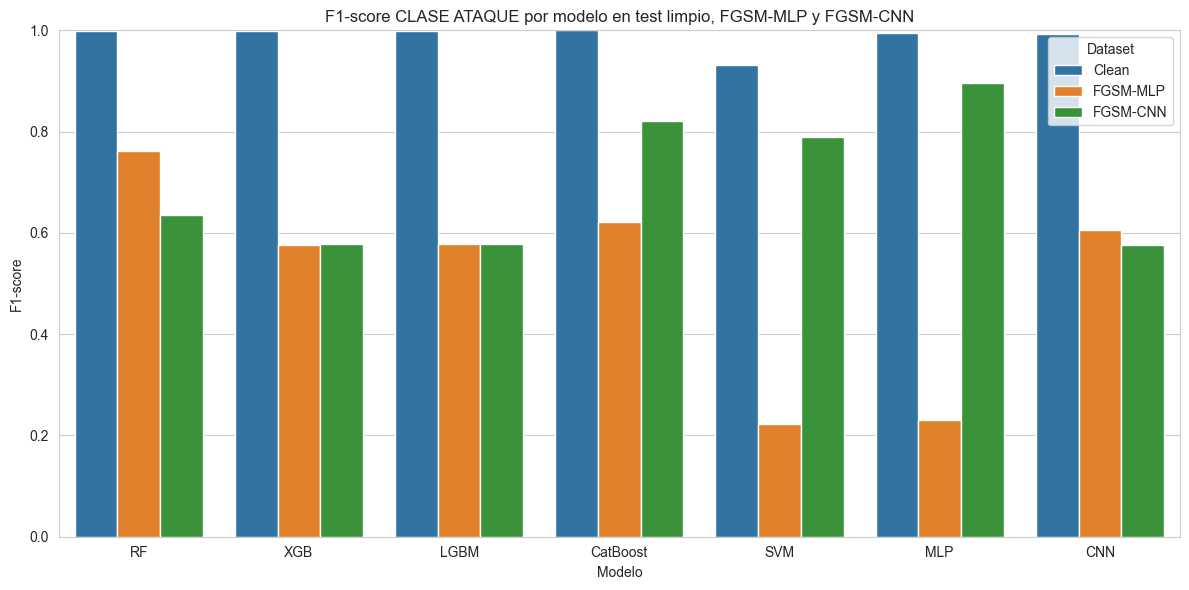

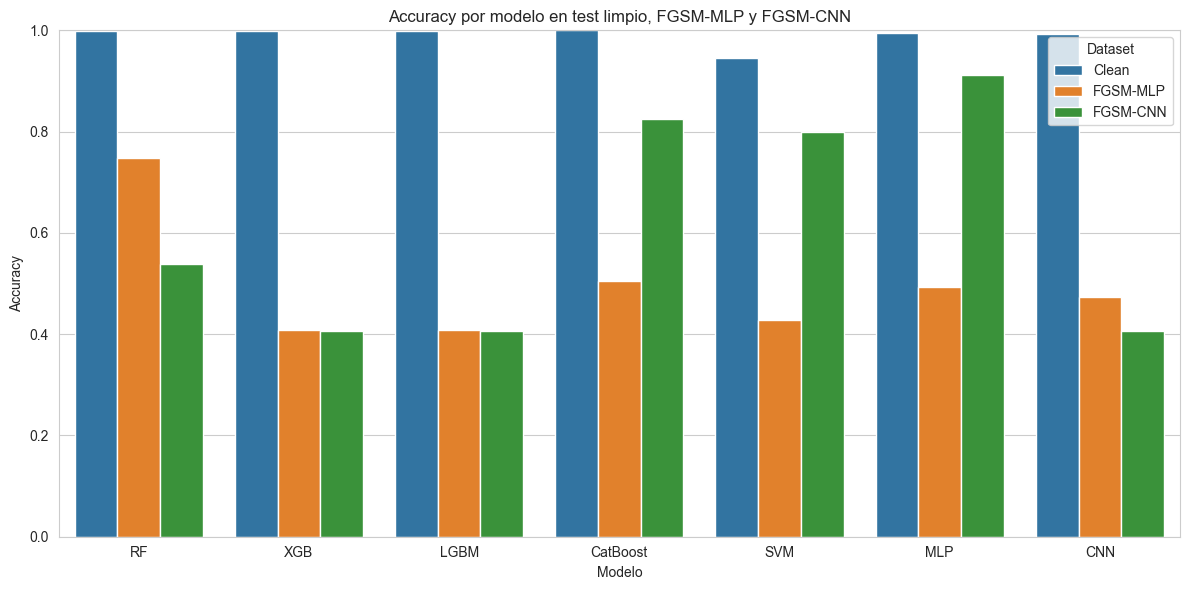

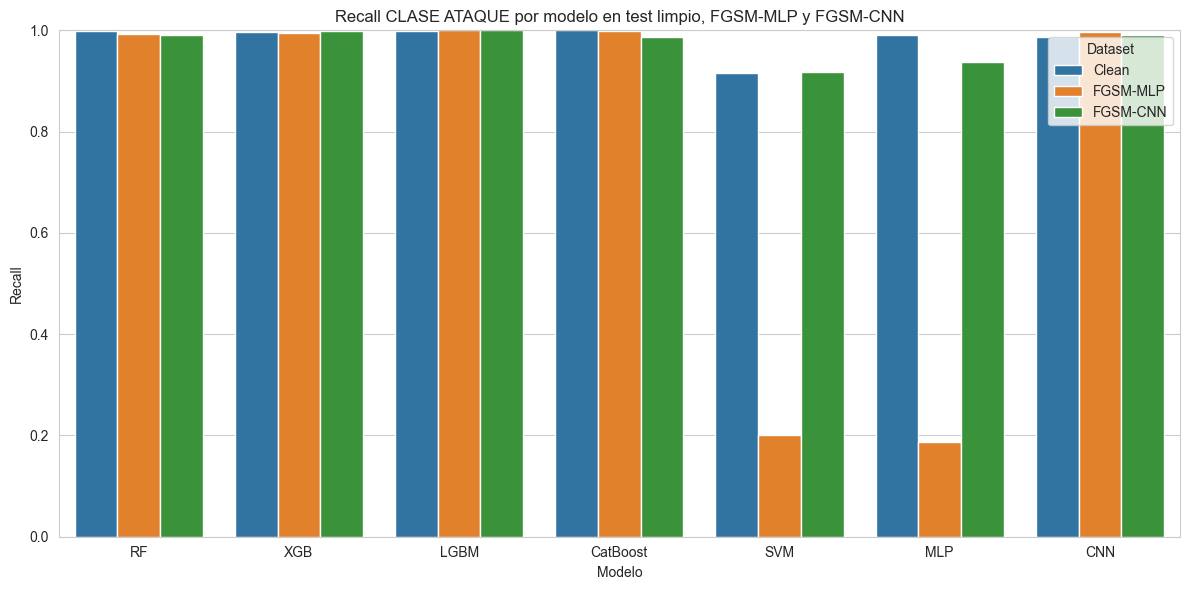

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# F1-score
# ============================================================

results_f1 = [
    {"Modelo": "RF", "Dataset": "Clean", "F1": rf_f1_clean},
    {"Modelo": "RF", "Dataset": "FGSM-MLP", "F1": rf_f1_fgsm_mlp},
    {"Modelo": "RF", "Dataset": "FGSM-CNN", "F1": rf_f1_fgsm_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "F1": xgb_f1_clean},
    {"Modelo": "XGB", "Dataset": "FGSM-MLP", "F1": xgb_f1_fgsm_mlp},
    {"Modelo": "XGB", "Dataset": "FGSM-CNN", "F1": xgb_f1_fgsm_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "F1": lgbm_f1_clean},
    {"Modelo": "LGBM", "Dataset": "FGSM-MLP", "F1": lgbm_f1_fgsm_mlp},
    {"Modelo": "LGBM", "Dataset": "FGSM-CNN", "F1": lgbm_f1_fgsm_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "F1": cat_f1_clean},
    {"Modelo": "CatBoost", "Dataset": "FGSM-MLP", "F1": cat_f1_fgsm_mlp},
    {"Modelo": "CatBoost", "Dataset": "FGSM-CNN", "F1": cat_f1_fgsm_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "F1": svm_f1_clean},
    {"Modelo": "SVM", "Dataset": "FGSM-MLP", "F1": svm_f1_fgsm_mlp},
    {"Modelo": "SVM", "Dataset": "FGSM-CNN", "F1": svm_f1_fgsm_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "F1": mlp_f1_clean},
    {"Modelo": "MLP", "Dataset": "FGSM-MLP", "F1": mlp_f1_fgsm_mlp},
    {"Modelo": "MLP", "Dataset": "FGSM-CNN", "F1": mlp_f1_fgsm_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "F1": cnn_f1_clean},
    {"Modelo": "CNN", "Dataset": "FGSM-MLP", "F1": cnn_f1_fgsm_mlp},
    {"Modelo": "CNN", "Dataset": "FGSM-CNN", "F1": cnn_f1_fgsm_cnn},
]

df_f1 = pd.DataFrame(results_f1)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_f1,
    x="Modelo",
    y="F1",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "FGSM-MLP", "FGSM-CNN"]
)

plt.title("F1-score CLASE ATAQUE por modelo en test limpio, FGSM-MLP y FGSM-CNN")
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# Accuracy
# ============================================================

results_acc = [
    {"Modelo": "RF", "Dataset": "Clean", "Accuracy": rf_acc_clean},
    {"Modelo": "RF", "Dataset": "FGSM-MLP", "Accuracy": rf_acc_fgsm_mlp},
    {"Modelo": "RF", "Dataset": "FGSM-CNN", "Accuracy": rf_acc_fgsm_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "Accuracy": xgb_acc_clean},
    {"Modelo": "XGB", "Dataset": "FGSM-MLP", "Accuracy": xgb_acc_fgsm_mlp},
    {"Modelo": "XGB", "Dataset": "FGSM-CNN", "Accuracy": xgb_acc_fgsm_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "Accuracy": lgbm_acc_clean},
    {"Modelo": "LGBM", "Dataset": "FGSM-MLP", "Accuracy": lgbm_acc_fgsm_mlp},
    {"Modelo": "LGBM", "Dataset": "FGSM-CNN", "Accuracy": lgbm_acc_fgsm_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "Accuracy": cat_acc_clean},
    {"Modelo": "CatBoost", "Dataset": "FGSM-MLP", "Accuracy": cat_acc_fgsm_mlp},
    {"Modelo": "CatBoost", "Dataset": "FGSM-CNN", "Accuracy": cat_acc_fgsm_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "Accuracy": svm_acc_clean},
    {"Modelo": "SVM", "Dataset": "FGSM-MLP", "Accuracy": svm_acc_fgsm_mlp},
    {"Modelo": "SVM", "Dataset": "FGSM-CNN", "Accuracy": svm_acc_fgsm_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "Accuracy": mlp_acc_clean},
    {"Modelo": "MLP", "Dataset": "FGSM-MLP", "Accuracy": mlp_acc_fgsm_mlp},
    {"Modelo": "MLP", "Dataset": "FGSM-CNN", "Accuracy": mlp_acc_fgsm_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "Accuracy": cnn_acc_clean},
    {"Modelo": "CNN", "Dataset": "FGSM-MLP", "Accuracy": cnn_acc_fgsm_mlp},
    {"Modelo": "CNN", "Dataset": "FGSM-CNN", "Accuracy": cnn_acc_fgsm_cnn},
]

df_acc = pd.DataFrame(results_acc)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_acc,
    x="Modelo",
    y="Accuracy",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "FGSM-MLP", "FGSM-CNN"]
)

plt.title("Accuracy por modelo en test limpio, FGSM-MLP y FGSM-CNN")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# Recall
# ============================================================

results_recall = [
    {"Modelo": "RF", "Dataset": "Clean", "Recall": rf_recall_clean},
    {"Modelo": "RF", "Dataset": "FGSM-MLP", "Recall": rf_recall_fgsm_mlp},
    {"Modelo": "RF", "Dataset": "FGSM-CNN", "Recall": rf_recall_fgsm_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "Recall": xgb_recall_clean},
    {"Modelo": "XGB", "Dataset": "FGSM-MLP", "Recall": xgb_recall_fgsm_mlp},
    {"Modelo": "XGB", "Dataset": "FGSM-CNN", "Recall": xgb_recall_fgsm_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "Recall": lgbm_recall_clean},
    {"Modelo": "LGBM", "Dataset": "FGSM-MLP", "Recall": lgbm_recall_fgsm_mlp},
    {"Modelo": "LGBM", "Dataset": "FGSM-CNN", "Recall": lgbm_recall_fgsm_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "Recall": cat_recall_clean},
    {"Modelo": "CatBoost", "Dataset": "FGSM-MLP", "Recall": cat_recall_fgsm_mlp},
    {"Modelo": "CatBoost", "Dataset": "FGSM-CNN", "Recall": cat_recall_fgsm_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "Recall": svm_recall_clean},
    {"Modelo": "SVM", "Dataset": "FGSM-MLP", "Recall": svm_recall_fgsm_mlp},
    {"Modelo": "SVM", "Dataset": "FGSM-CNN", "Recall": svm_recall_fgsm_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "Recall": mlp_recall_clean},
    {"Modelo": "MLP", "Dataset": "FGSM-MLP", "Recall": mlp_recall_fgsm_mlp},
    {"Modelo": "MLP", "Dataset": "FGSM-CNN", "Recall": mlp_recall_fgsm_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "Recall": cnn_recall_clean},
    {"Modelo": "CNN", "Dataset": "FGSM-MLP", "Recall": cnn_recall_fgsm_mlp},
    {"Modelo": "CNN", "Dataset": "FGSM-CNN", "Recall": cnn_recall_fgsm_cnn},
]

df_recall = pd.DataFrame(results_recall)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_recall,
    x="Modelo",
    y="Recall",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "FGSM-MLP", "FGSM-CNN"]
)

plt.title("Recall CLASE ATAQUE por modelo en test limpio, FGSM-MLP y FGSM-CNN")
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()
